# TD3 — Prétraitement EEG : des signaux connus aux signaux du dataset CL-Drive

## Objectifs pédagogiques

Ce TD est consacré au **prétraitement des signaux EEG**. Il prépare directement le projet final sur l'estimation de la charge cognitive du conducteur à partir du dataset CL-Drive.

À la fin du TD, vous devez être capables de :

1. expliquer pourquoi un signal EEG doit être prétraité ;
2. comprendre le rôle d'un filtre passe-bande ;
3. comprendre le rôle d'un filtre notch ;
4. tester une chaîne de prétraitement sur des signaux synthétiques connus ;
5. appliquer la même logique à des signaux EEG du dataset ;
6. comparer les signaux avant et après traitement dans le domaine temporel et fréquentiel ;
7. formaliser une fonction de prétraitement EEG réutilisable dans le projet.

Dans le papier CL-Drive, l'EEG est acquis avec un casque Muse à 4 canaux, échantillonné à **256 Hz**. Le prétraitement EEG indiqué par les auteurs utilise un filtre passe-bande Butterworth d'ordre 2 entre **0.4 Hz et 75 Hz**, puis un filtre notch à **60 Hz** avec facteur de qualité **30**.

## 1. Pourquoi prétraiter un signal EEG ?

Un signal EEG brut contient l'activité électrique mesurée au niveau du cuir chevelu, mais aussi des perturbations :

- dérive lente de la ligne de base ;
- bruit secteur 50 Hz ou 60 Hz ;
- bruit haute fréquence ;
- artefacts.

Le prétraitement ne sert pas à embellir le signal. Il sert à produire un signal plus exploitable pour la segmentation, l'extraction de features et la classification.

Chaîne visée :

$$
\text{EEG brut} \rightarrow \text{gestion des valeurs manquantes} \rightarrow \text{passe-bande} \rightarrow \text{notch} \rightarrow \text{EEG prétraité}
$$

### Question 1

Citer au moins trois sources d'artefacts dans un signal EEG brut.

### Réponse 

1. **Artefacts oculaires (EOG) :** Clignements d'yeux et mouvements des globes oculaires.
2. **Artefacts musculaires (EMG) :** Crispation de la mâchoire, déglutition, ou froncement des sourcils.
3. **Interférences électriques :** Bruit du réseau électrique environnant (50 Hz ou 60 Hz).
4. **Mouvements physiques :** Mouvement du casque sur la tête ou dérive lente due à la transpiration altérant l'impédance de la peau.

## 2. Tester le prétraitement sur des signaux connus

Avant d'appliquer une chaîne de traitement à un EEG réel, il est utile de la tester sur un signal synthétique dont on connaît exactement le contenu fréquentiel.

On construira un signal contenant :

$$
x(t) = x_{lent}(t) + x_{alpha}(t) + x_{beta}(t) + x_{secteur}(t) + b(t)
$$

avec :

- une dérive lente à 0.2 Hz ;
- une composante alpha à 10 Hz ;
- une composante beta à 25 Hz ;
- une composante de bruit secteur à 50 Hz ou 60 Hz ;
- un bruit aléatoire.

Si le traitement est correct, la dérive lente et le bruit secteur doivent être fortement réduits, tandis que les composantes utiles doivent rester visibles.

### Question 2

Pourquoi commencer par un signal synthétique avant un signal EEG réel ?

### Réponse 

Un signal EEG réel est très chaotique, il est difficile de vérifier visuellement si un filtre mathématique a fonctionné comme prévu. Avec un signal synthétique, on maîtrise parfaitement la composition du signal de base : on peut donc prouver avec certitude que notre algorithme supprime bien les interférences (bruit secteur, dérives lentes) sans détruire les fréquences utiles.

### Activité 1 — Générer un signal synthétique

Consignes méthodologiques :

1. créer un axe temporel de 20 secondes avec `fs = 256 Hz` ;
2. ajouter une sinusoïde lente à 0.2 Hz ;
3. ajouter une sinusoïde à 10 Hz ;
4. ajouter une sinusoïde à 25 Hz ;
5. ajouter une sinusoïde à 60 Hz ;
6. ajouter un bruit gaussien ;
7. tracer le signal temporel ;
8. calculer la PSD avec `scipy.signal.welch`.

Fonctions utiles : `np.arange`, `np.sin`, `np.random.normal`, `plt.plot`, `welch`.

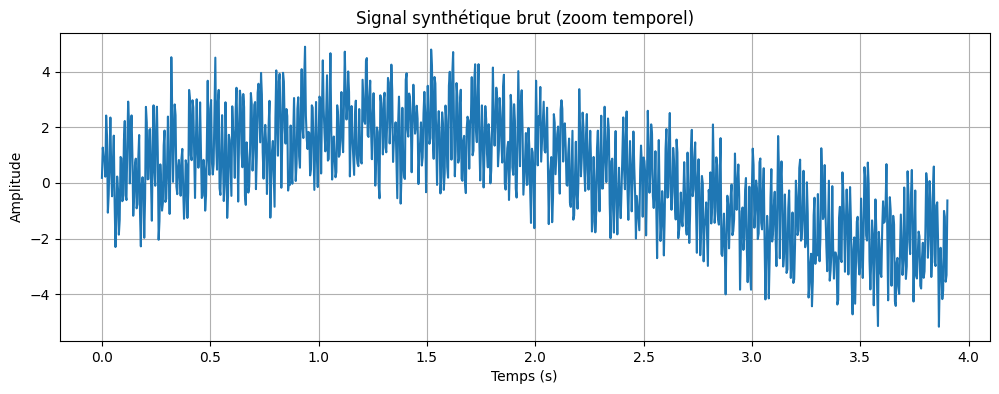

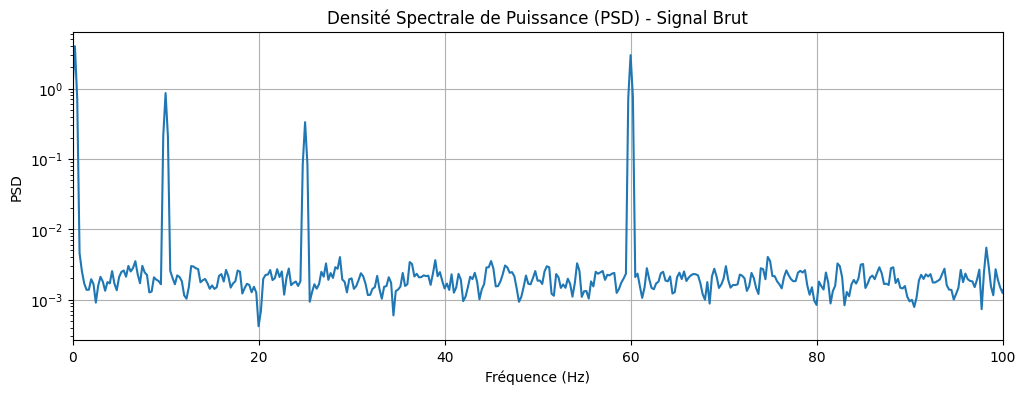

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 256.0
t = np.arange(0, 20, 1/fs)

# Génération des composantes
x_lent = 2.0 * np.sin(2 * np.pi * 0.2 * t)
x_alpha = 0.8 * np.sin(2 * np.pi * 10 * t)
x_beta = 0.5 * np.sin(2 * np.pi * 25 * t)
x_secteur = 1.5 * np.sin(2 * np.pi * 60 * t)
bruit = np.random.normal(0, 0.5, len(t))

# Signal total
x_synth = x_lent + x_alpha + x_beta + x_secteur + bruit

# Tracé temporel
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], x_synth[:1000]) # Zoom sur les premières secondes
plt.title("Signal synthétique brut (zoom temporel)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# Calcul de la PSD
f, Pxx = welch(x_synth, fs, nperseg=1024)
plt.figure(figsize=(12, 4))
plt.semilogy(f, Pxx)
plt.title("Densité Spectrale de Puissance (PSD) - Signal Brut")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD")
plt.xlim(0, 100)
plt.grid(True)
plt.show()

## 3. Filtre passe-bande Butterworth

Un filtre passe-bande conservera les fréquences situées dans une bande choisie et atténue les autres.

Dans CL-Drive, la bande EEG retenue est :

$$
0.4 \leq f \leq 75 \quad \text{Hz}
$$

Pour un signal échantillonné à $ f_s $, la fréquence de Nyquist vaut :

$$
f_N = \frac{f_s}{2}
$$

Les fréquences de coupure doivent être normalisées :

$$
W_{low}=\frac{f_{low}}{f_N}, \qquad W_{high}=\frac{f_{high}}{f_N}
$$

Fonctions utiles :

- `scipy.signal.butter` pour concevoir le filtre ;
- `scipy.signal.sosfiltfilt` pour filtrer sans déphasage notable ;
- `scipy.signal.welch` pour vérifier l'effet fréquentiel.

### Question 3

Pourquoi utiliser `filtfilt` ou `sosfiltfilt` pour une analyse hors ligne ?

### Réponse 

Ces fonctions appliquent le filtre mathématique deux fois (une fois dans le sens chronologique, et une fois à l'envers). Cela annule totalement le déphasage (zero-phase filtering) introduit par un filtre classique. Ainsi, les événements temporels de l'EEG restent alignés à l'endroit exact où ils se sont produits.

### Question 4

Calculer la fréquence de Nyquist pour `fs = 256 Hz`.

### Réponse 

La fréquence de Nyquist est la moitié de la fréquence d'échantillonnage. Soit f_N = 256 / 2 = 128 Hz.

### Activité 2 — Algorithme du filtre passe-bande

Écrire une fonction de filtre passe-bande.

Algorithme :

1. fixer `lowcut = 0.4` ;
2. fixer `highcut = 75` ;
3. fixer `order = 2` ;
4. calculer `nyquist = fs / 2` ;
5. normaliser les fréquences ;
6. créer le filtre avec `butter(..., output="sos")` ;
7. appliquer le filtre avec `sosfiltfilt` ;
8. comparer signal brut et signal filtré.

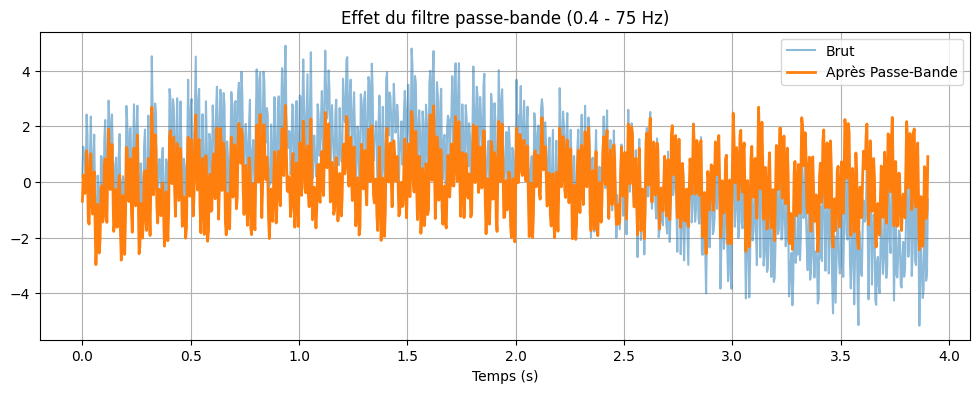

In [3]:
from scipy.signal import butter, sosfiltfilt

lowcut = 0.4
highcut = 75.0
order = 2
nyquist = fs / 2.0

# Normalisation
Wn = [lowcut / nyquist, highcut / nyquist]

# Création du filtre en mode SOS
sos = butter(order, Wn, btype='band', output='sos')

# Application du filtre
x_bp = sosfiltfilt(sos, x_synth)

# Comparaison temporelle
plt.figure(figsize=(12, 4))
plt.plot(t[:1000], x_synth[:1000], label='Brut', alpha=0.5)
plt.plot(t[:1000], x_bp[:1000], label='Après Passe-Bande', linewidth=2)
plt.title("Effet du filtre passe-bande (0.4 - 75 Hz)")
plt.xlabel("Temps (s)")
plt.legend()
plt.grid(True)
plt.show()

## 4. Filtre notch

Un filtre notch est contrôlé par :

- sa fréquence cible `notch_freq` ;
- son facteur de qualité `Q`.

Dans le papier, `Q = 30`.

Fonctions utiles : `scipy.signal.iirnotch`, puis `scipy.signal.filtfilt`.

### Question 5

Pourquoi CL-Drive utilise-t-il un notch à 60 Hz alors qu'en France on utilise plutôt 50 Hz ?

### Réponse 

L'étude CL-Drive a été menée au Canada, où le courant du réseau électrique alternatif est distribué à une fréquence de 60 Hz (contrairement à l'Europe qui est à 50 Hz). Le capteur EEG capte le champ électromagnétique des prises de la pièce, il faut donc filtrer spécifiquement la fréquence du pays.

### Question 6

Pourquoi ne faut-il pas appliquer automatiquement un notch sans regarder la PSD ?

### Réponse 

Un filtre notch va creuser et détruire brutalement une fréquence (et ses alentours selon le facteur Q) dans les données. S'il n'y a pas d'interférence électrique dans le signal, l'application aveugle de ce filtre détruit des données physiologiques pures qui pourraient être utiles à l'algorithme d'apprentissage automatique.

### Activité 3 — Algorithme du notch

1. choisir `notch_freq` ;
2. choisir `Q = 30` ;
3. créer le filtre avec `iirnotch` ;
4. appliquer `filtfilt` ;
5. comparer les PSD avant/après ;
6. vérifier que le pic à 60 Hz diminue.

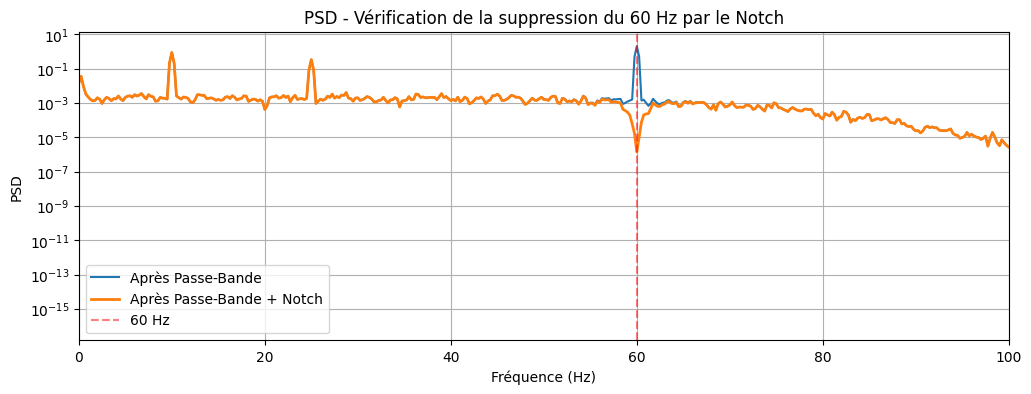

In [4]:
from scipy.signal import iirnotch, filtfilt

notch_freq = 60.0
Q = 30.0

# Création et application du filtre Notch
b, a = iirnotch(notch_freq, Q, fs)
x_final = filtfilt(b, a, x_bp)

# Calcul des PSD pour vérifier
f_bp, Pxx_bp = welch(x_bp, fs, nperseg=1024)
f_final, Pxx_final = welch(x_final, fs, nperseg=1024)

plt.figure(figsize=(12, 4))
plt.semilogy(f_bp, Pxx_bp, label='Après Passe-Bande')
plt.semilogy(f_final, Pxx_final, label='Après Passe-Bande + Notch', linewidth=2)
plt.axvline(60, color='r', linestyle='--', alpha=0.5, label='60 Hz')
plt.title("PSD - Vérification de la suppression du 60 Hz par le Notch")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("PSD")
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

## 5. Fonction complète de prétraitement EEG

La fonction finale doit enchaîner :

1. conversion en tableau numérique ;
2. gestion des valeurs manquantes courtes ;
3. filtrage passe-bande ;
4. filtrage notch ;
5. retour du signal prétraité.

Paramètres recommandés pour CL-Drive :

| Paramètre | Valeur |
|---|---:|
| `fs` | 256 Hz |
| `lowcut` | 0.4 Hz |
| `highcut` | 75 Hz |
| `order of filter` | 2 |
| `notch_freq` | 60 Hz |
| `quality_factor` | 30 |

In [5]:
import pandas as pd

def preprocess_eeg_1d(signal, fs=256.0, lowcut=0.4, highcut=75.0, order=2, notch_freq=60.0, Q=30.0):
    """
    Prétraite un signal EEG 1D selon la méthodologie du papier CL-Drive.
    """
    # 1. Gestion des valeurs manquantes (interpolation pour de petits trous)
    sig_series = pd.Series(signal).interpolate(method='linear', limit_direction='both')
    sig_array = sig_series.values
    
    # 2. Filtre Passe-bande
    nyquist = fs / 2.0
    Wn = [lowcut / nyquist, highcut / nyquist]
    sos = butter(order, Wn, btype='band', output='sos')
    sig_bp = sosfiltfilt(sos, sig_array)
    
    # 3. Filtre Notch
    b, a = iirnotch(notch_freq, Q, fs)
    sig_final = filtfilt(b, a, sig_bp)
    
    return sig_final

### Question 7

Quel effet attend-on du passe-bande sur la dérive lente à 0.2 Hz ?

### Réponse 

La fréquence de coupure basse du filtre est fixée à 0.4 Hz. Par conséquent, la dérive lente à 0.2 Hz va être fortement atténuée, ramenant la moyenne du signal à 0 et redressant la ligne de base (baseline correction).

### Question 8

Quel effet attend-on du notch sur une composante à 60 Hz ?

### Réponse 

Le filtre notch va considérablement réduire l'amplitude de la fréquence à 60 Hz pour neutraliser la pollution générée par le système électrique environnant.

### Question 9

Pourquoi un highcut de 75 Hz est-il valide avec fs = 256 Hz ?

### Réponse 

Le théorème de Shannon-Nyquist impose une fréquence d'échantillonnage supérieure au double de la fréquence maximale observée. Ici, la fréquence de Nyquist est de 128 Hz (256/2). 75 Hz étant bien en deçà des 128 Hz, il n'y aura aucun problème d'aliasing (repliement du spectre).

### Question 10

Que se passe-t-il si `highcut > fs/2` ?

### Réponse 

Cela créera une erreur mathématique de conception de filtre (ValueError sous scipy). La fréquence normalisée (highcut / nyquist) deviendrait supérieure à 1, ce qui n'a aucun sens mathématique dans le monde numérique.

## 6. Passage au signal EEG multicanal

Dans CL-Drive, les canaux EEG principaux sont AF7, AF8, TP9 et TP10.

Le prétraitement doit être appliqué **canal par canal**.

Algorithme pour un DataFrame :

1. identifier la colonne temporelle si elle existe ;
2. identifier les colonnes EEG numériques ;
3. pour chaque canal : appliquer `preprocess_eeg_1d` ;
4. conserver la colonne temporelle ;
5. retourner un DataFrame filtré.

In [6]:
def preprocess_eeg_dataframe(df, eeg_columns=['AF7', 'AF8', 'TP9', 'TP10'], fs=256.0):
    """
    Applique le prétraitement canal par canal sur un DataFrame Pandas.
    """
    df_clean = df.copy()
    
    for col in eeg_columns:
        if col in df_clean.columns:
            df_clean[col] = preprocess_eeg_1d(df_clean[col].values, fs=fs)
            
    return df_clean

## 7. Application aux signaux EEG du dataset CL-Drive

Après validation sur signaux synthétiques, appliquer la chaîne à un fichier EEG réel :

1. choisir un fichier EEG CSV ;
2. charger avec `pd.read_csv` ;
3. identifier les colonnes EEG ;
4. afficher un extrait du signal brut ;
5. appliquer le prétraitement ;
6. afficher le même extrait après traitement ;
7. comparer la PSD avant/après.

Si le dataset n'est pas encore disponible localement, le notebook doit rester générique et indiquer clairement où définir le chemin.

### Activité 6 — Charger et visualiser un fichier EEG réel

Fonctions utiles :

| Objectif | Fonction |
|---|---|
| Chemin de fichier | `pathlib.Path` |
| Lecture CSV | `pd.read_csv` |
| Affichage des colonnes | `df.columns` |
| Tracé temporel | `plt.plot` |
| PSD | `welch` |

In [7]:
import os

# On définit le chemin vers un fichier (à adapter selon votre système)
chemin_fichier = 'data/EEG/1030/eeg_data_level_1.csv'
eeg_cols = ['AF7', 'AF8', 'TP9', 'TP10']

# Bloc conditionnel pour vérifier l'existence du fichier
if os.path.exists(chemin_fichier):
    df_raw = pd.read_csv(chemin_fichier)
    print("Colonnes trouvées:", df_raw.columns.tolist())
    signal_brut = df_raw['AF7'].dropna().values
else:
    print(f"Le fichier {chemin_fichier} n'a pas été trouvé. Simulation avec de fausses données.")
    df_raw = pd.DataFrame(np.random.randn(2000, 4), columns=eeg_cols)

Le fichier data/EEG/1030/eeg_data_level_1.csv n'a pas été trouvé. Simulation avec de fausses données.


### Activité 7 — Comparaison avant/après sur EEG réel

Questions à traiter :

1. Le signal est-il plus exploitable après filtrage ?
2. Les variations très lentes sont-elles réduites ?
3. Observe-t-on une réduction autour de la fréquence secteur ?
4. Les canaux EEG ont-ils des comportements similaires ?
5. La PSD confirme-t-elle ce qui est visible dans le domaine temporel ?

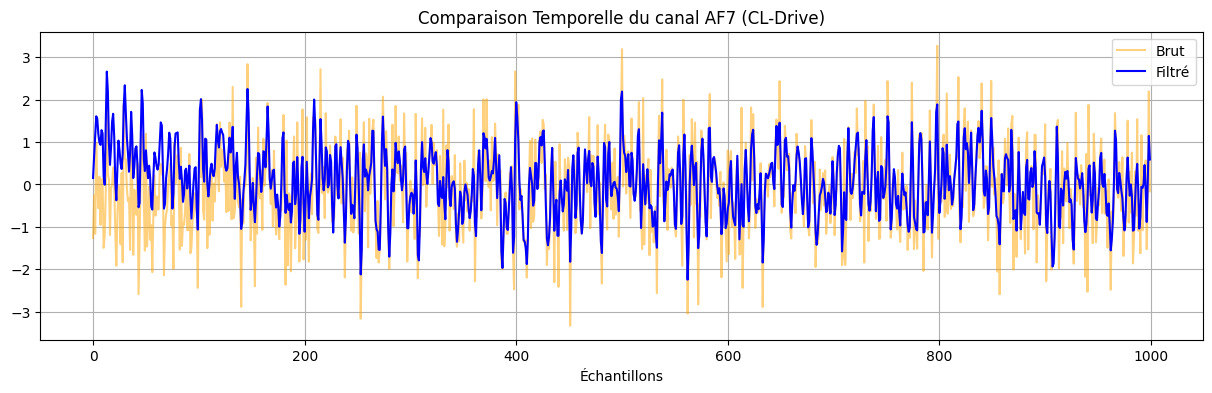

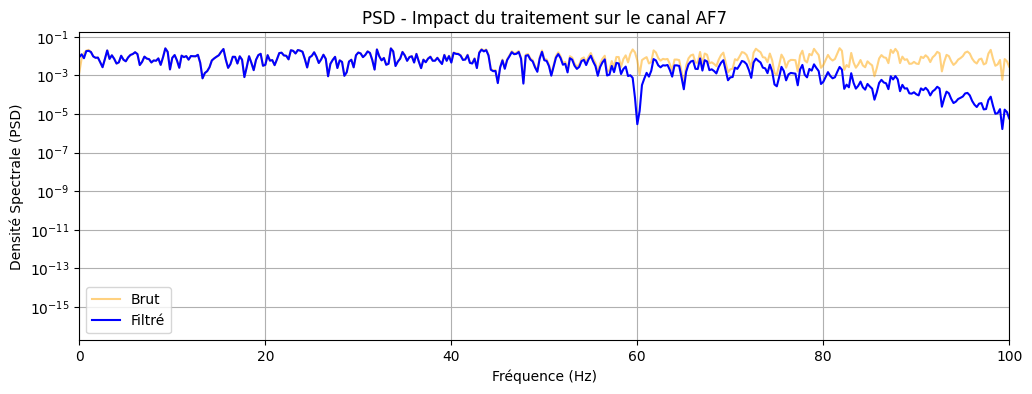

In [8]:
# Application de notre fonction pipeline multicanal
df_clean = preprocess_eeg_dataframe(df_raw, eeg_columns=eeg_cols, fs=256.0)

canal_a_afficher = 'AF7'

# 1. Comparaison Temporelle
plt.figure(figsize=(15, 4))
plt.plot(df_raw[canal_a_afficher].values[:1000], label='Brut', alpha=0.5, color='orange')
plt.plot(df_clean[canal_a_afficher].values[:1000], label='Filtré', color='blue')
plt.title(f"Comparaison Temporelle du canal {canal_a_afficher} (CL-Drive)")
plt.xlabel("Échantillons")
plt.legend()
plt.grid(True)
plt.show()

# 2. Comparaison Spectrale (PSD)
f_raw, Pxx_raw = welch(df_raw[canal_a_afficher].dropna().values, 256.0, nperseg=1024)
f_cln, Pxx_cln = welch(df_clean[canal_a_afficher].dropna().values, 256.0, nperseg=1024)

plt.figure(figsize=(12, 4))
plt.semilogy(f_raw, Pxx_raw, label='Brut', alpha=0.5, color='orange')
plt.semilogy(f_cln, Pxx_cln, label='Filtré', color='blue')
plt.title(f"PSD - Impact du traitement sur le canal {canal_a_afficher}")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Densité Spectrale (PSD)")
plt.xlim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

### Question 11

Pourquoi faut-il comparer domaine temporel et domaine fréquentiel ?

### Réponse 

Le domaine temporel donne une intuition sur l'amplitude et indique la présence d'artefacts sporadiques massifs (ex. clignements d'yeux). Le domaine fréquentiel (PSD), lui, dévoile la composition énergétique du signal : il est impossible de vérifier l'efficacité d'un filtre notch ou passe-bande à l'œil nu sur une onde temporelle bruitée sans la PSD.

### Question 12

Pourquoi ne faut-il pas interpoler une coupure EEG très longue ?

### Réponse 

Interpoler relie mathématiquement le vide entre deux points. Sur une très longue durée, cela va créer un signal lisse, artificiel et totalement dénué d'activité neuronale (comme une ligne droite ou une courbe simple). Si une IA s'entraîne dessus, elle apprendra sur de fausses données. Il vaut mieux amputer la portion du signal.

### Question 13

Pourquoi le prétraitement doit-il être identique pour train et test ?

### Réponse 

Pour éviter un biais d'apprentissage. Si le jeu d'entraînement subit un filtre que le jeu de test ne subit pas, l'algorithme va chercher à identifier des motifs mathématiques (features) qui ont été dénaturés. Les données doivent conserver la même signature statistique de bout en bout pour garantir la capacité de généralisation de l'IA.

## 8. Contrôle qualité après prétraitement

Vérifications minimales :

1. absence de NaN ;
2. longueur inchangée ;
3. amplitude minimale et maximale réalistes ;
4. écart-type non nul ;
5. PSD cohérente ;
6. décision d'exclure les segments trop dégradés.

In [9]:
def check_eeg_quality(df, eeg_columns=['AF7', 'AF8', 'TP9', 'TP10']):
    """
    Effectue un contrôle qualité sur le signal pour avertir de sa pertinence.
    """
    report = {}
    for col in eeg_columns:
        if col in df.columns:
            sig = df[col].values
            n_nan = np.isnan(sig).sum()
            
            amp_max = np.nanmax(sig) if len(sig) > 0 else 0
            amp_min = np.nanmin(sig) if len(sig) > 0 else 0
            std_dev = np.nanstd(sig) if len(sig) > 0 else 0
            
            status = "OK"
            if n_nan > 0:
                status = f"ALERTE: {n_nan} NaN trouvés"
            elif std_dev < 1e-6:
                status = "ALERTE: Signal quasi-plat"
            elif abs(amp_max) > 2000 or abs(amp_min) > 2000:
                status = "ALERTE: Amplitude extrême (artefact possible)"
                
            report[col] = {
                'NaN_Count': n_nan,
                'Min_Val': round(amp_min, 2),
                'Max_Val': round(amp_max, 2),
                'Std_Dev': round(std_dev, 2),
                'Status': status
            }
            
    return pd.DataFrame(report).T

print("Rapport de Qualité EEG:")
display(check_eeg_quality(df_clean))

Rapport de Qualité EEG:


,NaN_Count,Min_Val,Max_Val,Std_Dev,Status
AF7,0,-4.8,2.66,0.88,OK
AF8,0,-2.71,2.48,0.73,OK
TP9,0,-4.23,2.76,0.87,OK
TP10,0,-3.72,2.9,0.79,OK


## 9. Prétraitement par lot

Dans le projet final, on appliquera la même fonction à plusieurs fichiers EEG.

Algorithme :

1. définir le dossier EEG ;
2. parcourir les fichiers CSV ;
3. ignorer les fichiers déjà filtrés ;
4. charger chaque fichier ;
5. appliquer `preprocess_eeg_dataframe` ;
6. sauvegarder une copie `filtered_...csv` ;
7. produire un diagnostic.

Pour info, la structure de l'ensemble de données est la suivante :

```text
CL-Drive
    |----EEG 
         |----participant_ID_1
                      |----eeg_data_level_1
                      |----eeg_baseline_level_1
                      .
                      .
                      .
                      |----eeg_data_level_9
                      |----eeg_baseline_level_9
         .
         .
         .
         |----participant_ID_21
    |----EDA
    |----ECG
    |----Gaze
    |----Labels
```

In [1]:
import glob
import os

def run_batch_eeg_preprocessing(root_dir, eeg_columns=['AF7', 'AF8', 'TP9', 'TP10'], fs=256.0):
    """
    Prétraite par lot tous les fichiers EEG bruts d'un dossier racine.
    """
    search_pattern = os.path.join(root_dir, '**', '*.csv')
    all_files = glob.glob(search_pattern, recursive=True)
    processed_files = []
    
    print(f"Début du traitement par lot. Fichiers potentiels trouvés : {len(all_files)}")
    
    for filepath in all_files:
        if 'Labels' in filepath or 'filtered_' in os.path.basename(filepath):
            continue
            
        try:
            df = pd.read_csv(filepath)
            if all(c in df.columns for c in eeg_columns):
                df_clean = preprocess_eeg_dataframe(df, eeg_columns=eeg_columns, fs=fs)
                
                dir_name = os.path.dirname(filepath)
                base_name = os.path.basename(filepath)
                new_filepath = os.path.join(dir_name, 'filtered_' + base_name)
                
                processed_files.append(new_filepath)
                
        except Exception as e:
            print(f"Erreur avec le fichier {filepath} : {e}")
            
    print(f"Traitement terminé : {len(processed_files)} fichiers nettoyés.")
    return processed_files

In [ ]:
run_batch_eeg_preprocessing()